In [1]:
import os
import pickle
import numpy as np
from utils.load_preprocess import load_preprocess
from utils.train_evaluate import bayesian_optimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from bayes_opt import BayesianOptimization

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
X = load_preprocess(n_genes, as_df=True)
y = X['class'].to_numpy()
X.drop('class', 1, inplace=True)

In [3]:
# # times to run bootstrap
n_bootstrap = 100

# # of hyperparameter combinations to try in random search
n_iter = 100

Bootstrap iteration # 1 out of 100
Bootstrap iteration # 2 out of 100
Bootstrap iteration # 3 out of 100
Bootstrap iteration # 4 out of 100
Bootstrap iteration # 5 out of 100
Bootstrap iteration # 6 out of 100
Bootstrap iteration # 7 out of 100
Bootstrap iteration # 8 out of 100
Bootstrap iteration # 9 out of 100
Bootstrap iteration # 10 out of 100
Bootstrap iteration # 11 out of 100
Bootstrap iteration # 12 out of 100
Bootstrap iteration # 13 out of 100
Bootstrap iteration # 14 out of 100
Bootstrap iteration # 15 out of 100
Bootstrap iteration # 16 out of 100
Bootstrap iteration # 17 out of 100
Bootstrap iteration # 18 out of 100
Bootstrap iteration # 19 out of 100
Bootstrap iteration # 20 out of 100
Bootstrap iteration # 21 out of 100
Bootstrap iteration # 22 out of 100
Bootstrap iteration # 23 out of 100
Bootstrap iteration # 24 out of 100
Bootstrap iteration # 25 out of 100
Bootstrap iteration # 26 out of 100
Bootstrap iteration # 27 out of 100
Bootstrap iteration # 28 out of 100
B

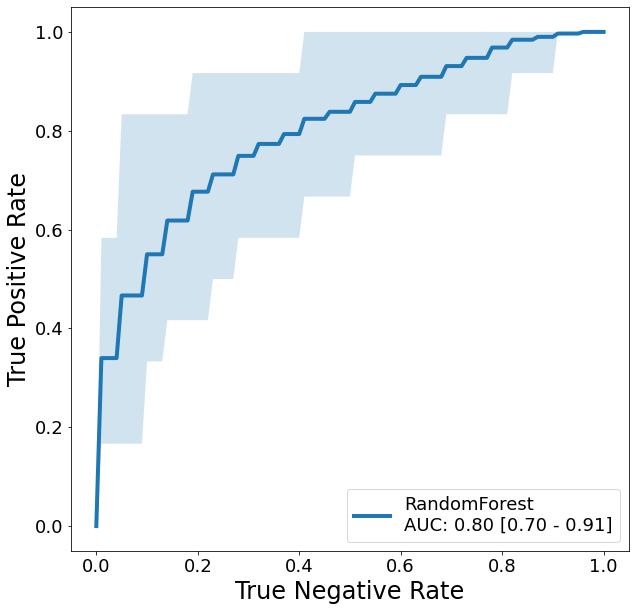

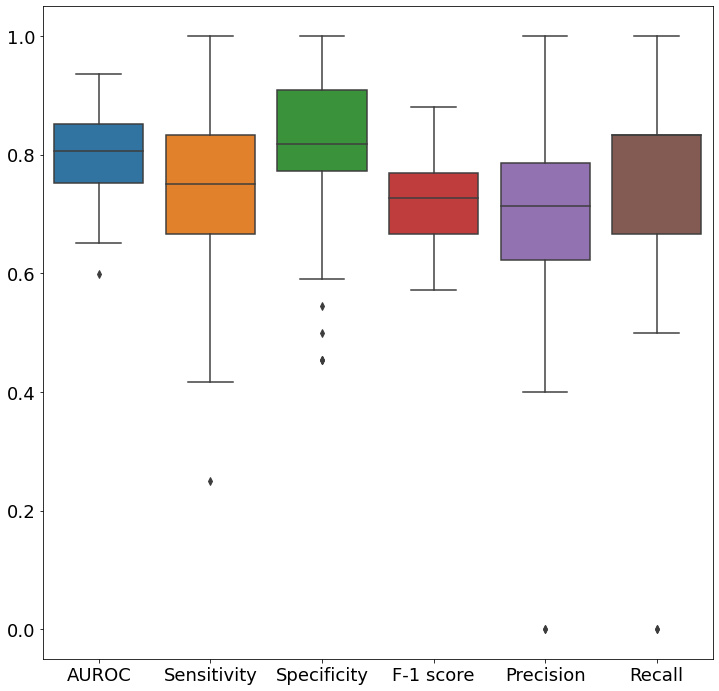

In [4]:
# Run Bayesian hyperparameter tuning
results_df, best_model_yet = bayesian_optimization(X,
                                                   y,
                                                   n_bootstrap=n_bootstrap,
                                                   model_type='random_forest',
                                                   n_iter=n_iter,
                                                   verbose=1,
                                                   plot_roc=True,
                                                   save_roc_fig=True,
                                                   plot_boxplot=True,
                                                   save_boxplot=True,
                                                   save_results=True,
                                                   path='results')

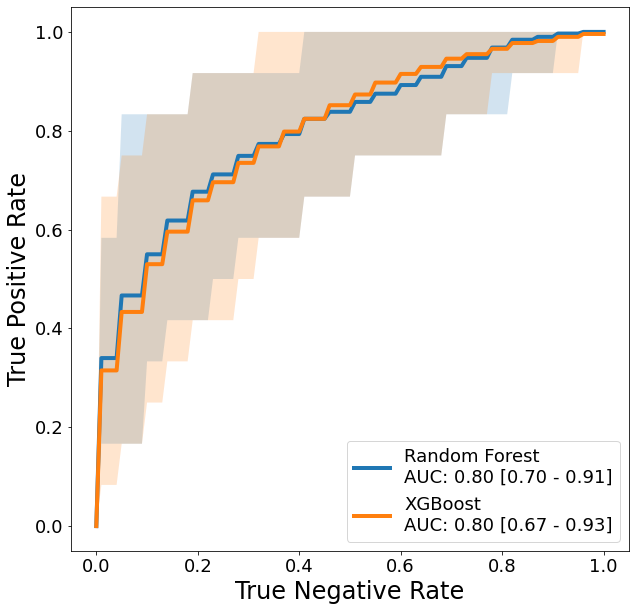

In [10]:
# Compare random forest and xgboost
with open(os.path.join('results', 'XGBoost_Bayesian_results.pkl'), 'rb') as f:
    xgboost_results_dict = pickle.load(f)
with open(os.path.join('results', 'RandomForest_Bayesian_results.pkl'), 'rb') as f:
    rf_results_dict = pickle.load(f)

# Plot and save figure
plt.figure(figsize=(10,10))
plt.xlabel('True Negative Rate', fontsize=24)
plt.ylabel('True Positive Rate', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=18)
ax = plt.gca()  # kwargs.pop('ax', plt.gca())
base_line, = ax.plot(rf_results_dict['fpr_grid_vec'],
                     rf_results_dict['tpr_mean'],
                     '-',
                     linewidth=4,
                     label='Random Forest\nAUC: {:.2f} [{:.2f} - {:.2f}]'.format(rf_results_dict['auroc_mean'],
                                                                           rf_results_dict['confidence_lower'],
                                                                           rf_results_dict['confidence_upper']))
ax.fill_between(rf_results_dict['fpr_grid_vec'],
                rf_results_dict['tpr_low_05'],
                rf_results_dict['tpr_top_95'],
                facecolor=base_line.get_color(), alpha=0.2);
base_line_xgboost, = ax.plot(xgboost_results_dict['fpr_grid_vec'],
                             xgboost_results_dict['tpr_mean'],
                             '-',
                             linewidth=4,
                             label='XGBoost\nAUC: {:.2f} [{:.2f} - {:.2f}]'.format(xgboost_results_dict['auroc_mean'],
                                                                                   xgboost_results_dict['confidence_lower'],
                                                                                   xgboost_results_dict['confidence_upper']))
ax.fill_between(xgboost_results_dict['fpr_grid_vec'],
                xgboost_results_dict['tpr_low_05'],
                xgboost_results_dict['tpr_top_95'],
                facecolor=base_line_xgboost.get_color(), alpha=0.2);
plt.legend(loc='lower right', fontsize=18);
plt.savefig(os.path.join('results', 'RandomForest_XGBoost_Bayesian_ROC_comparison.pdf'))

# Interpretation

In [11]:
import xgboost
import shap

In [ ]:
# # importance by weight
# _, ax_weight = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, ax=ax_weight)
# plt.title("xgboost.plot_importance(model)");

In [ ]:
# # importance by gain
# _, ax_gain = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='gain', ax=ax_gain)
# plt.title("xgboost.plot_importance(model)");

In [ ]:
# # importance by cover
# _, ax_cover = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='cover', ax=ax_cover)
# plt.title("xgboost.plot_importance(model)");

## The results are not consistent for xgboost plot_importance

# Using SHAP

In [12]:
import shap
explainer = shap.TreeExplainer(best_model_yet)
shap_values = explainer.shap_values(X)[1]

In [13]:
shap.initjs() 
shap.force_plot(explainer.expected_value[0], shap_values[0], X.iloc[0])

## The above looks similar to the weight method in xgboost plot_importance

In [14]:
shap.force_plot(explainer.expected_value[1], shap_values, X)

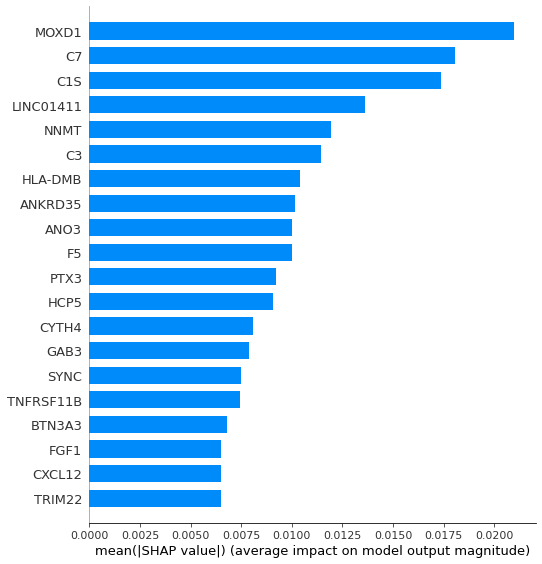

In [15]:
# Bar chart of mean importance
shap.summary_plot(shap_values, X, plot_type="bar")

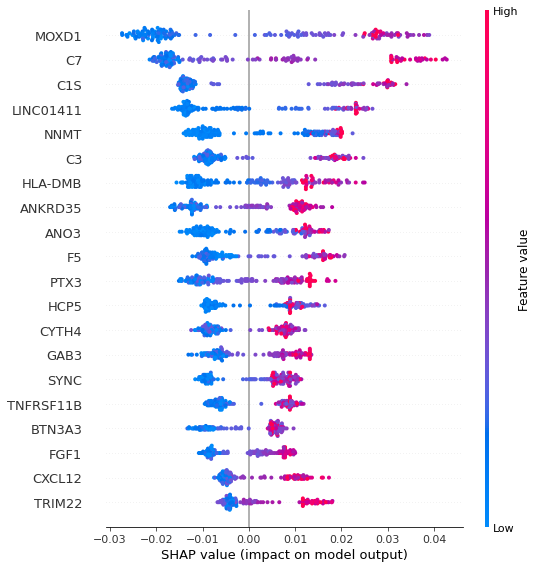

In [16]:
# Summary plot
shap.summary_plot(shap_values, X)

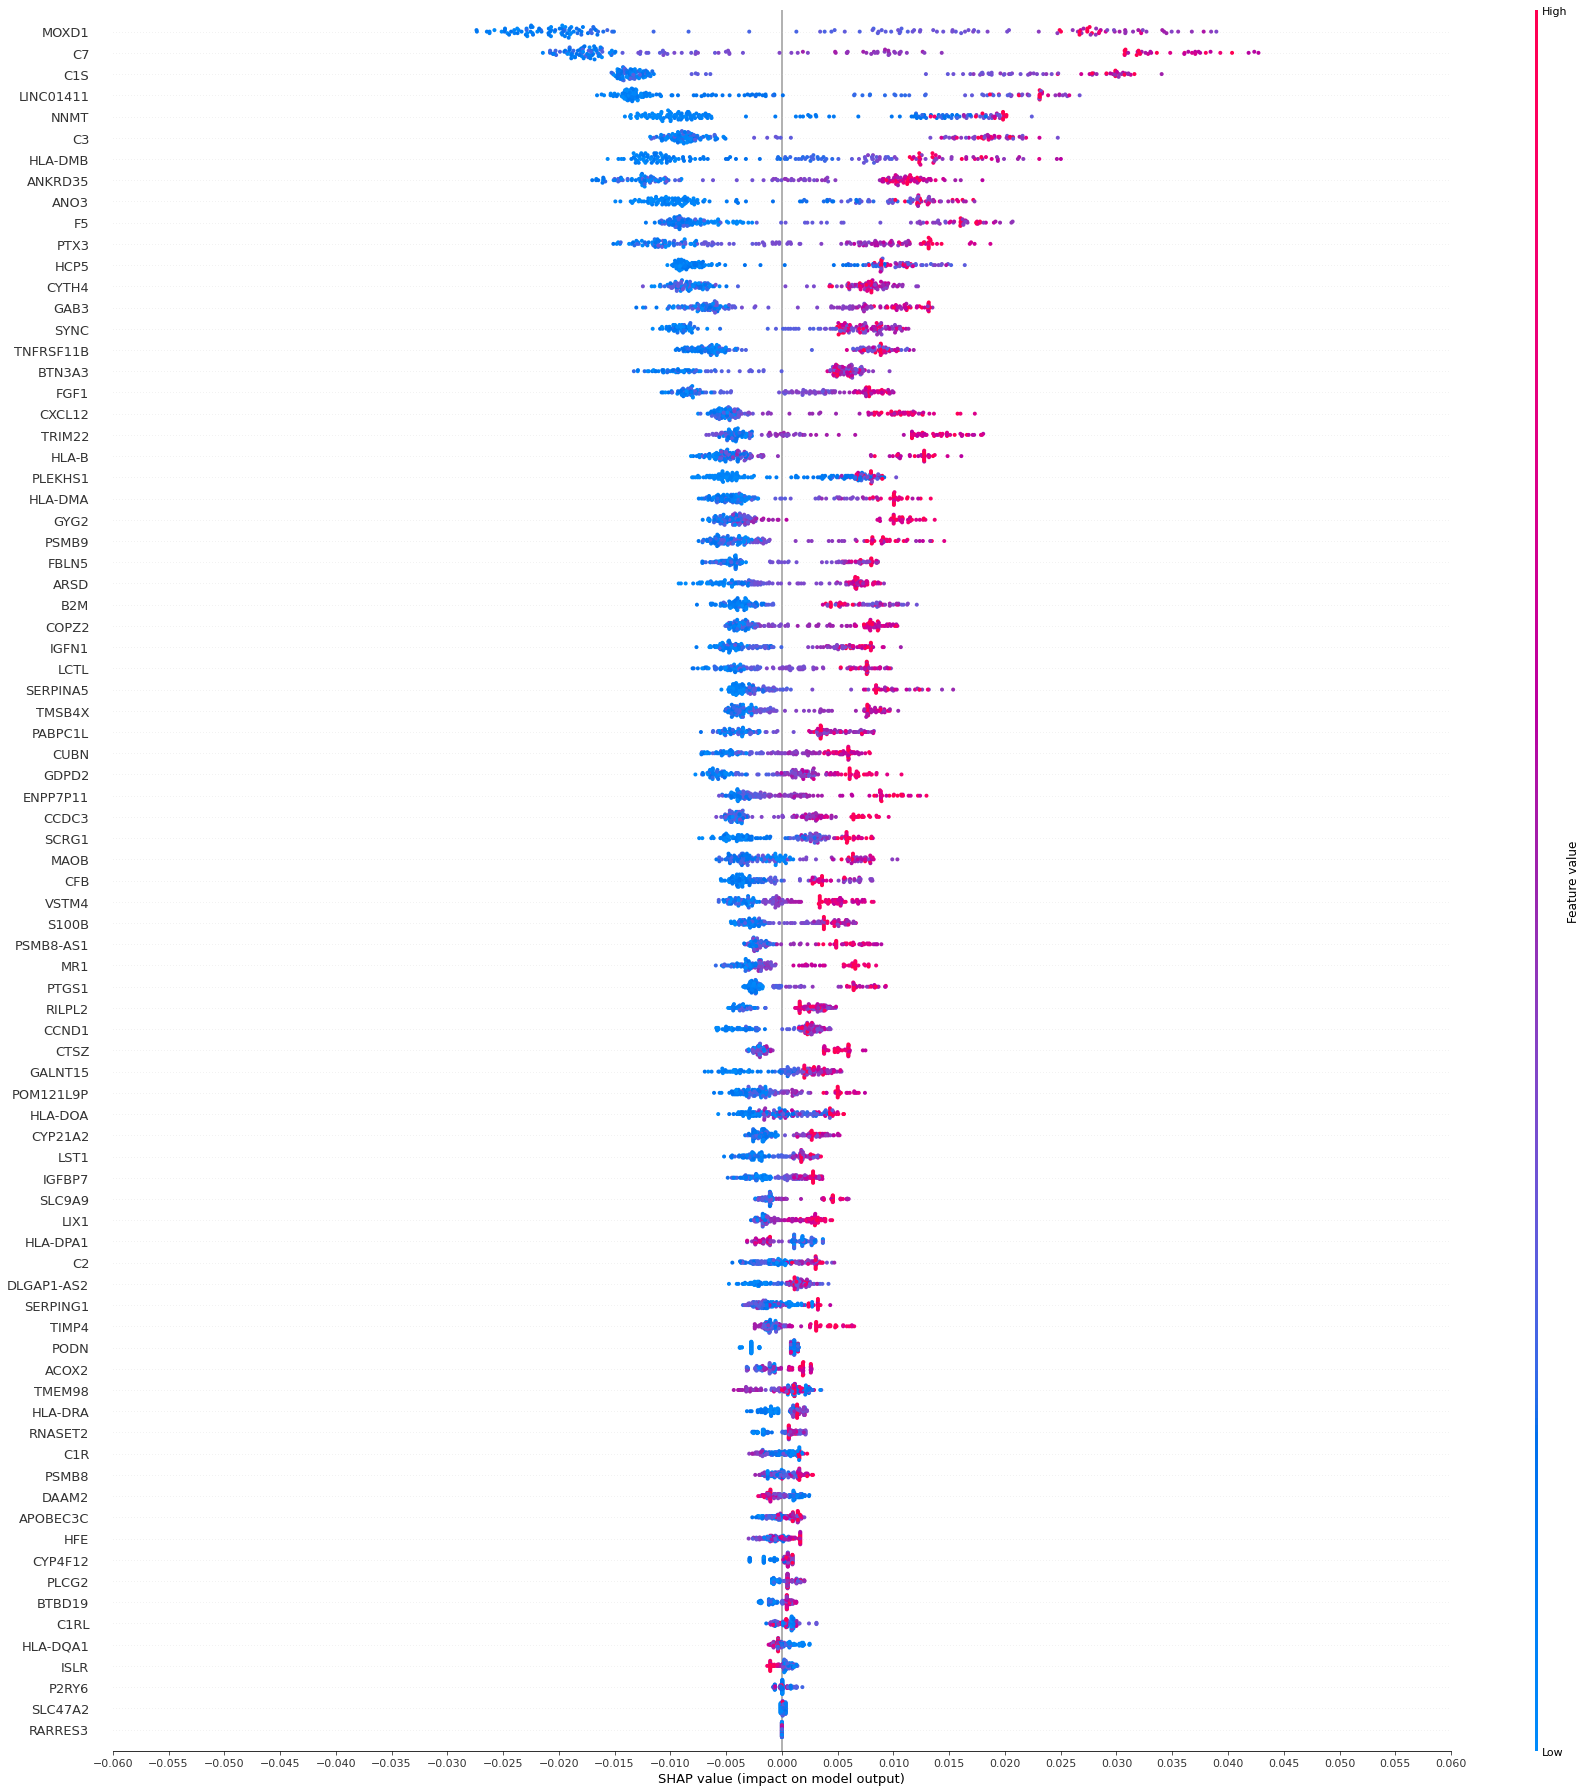

In [17]:
# Save SHAP summary
shap.summary_plot(shap_values, X, max_display=81, show=False)
f = plt.gcf()
ax = plt.gca()
f.set_size_inches(25, 25)
ax.set_xticks(np.linspace(-0.06, 0.06, 25, endpoint=True))
f.tight_layout()
f.savefig(os.path.join('results', 'RandomForest_Bayesian_shap_summary_plot.pdf'))

In [18]:
# Save shap_values and X so that we can plot later
shap_dict = {'X': X,
             'shap_values': shap_values}
with open(os.path.join('results', 'RandomForest_Bayesian_shap.pkl'), 'wb') as f:
    pickle.dump(shap_dict, f)